In [64]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import seaborn as sns

from sample_dataset import sample_dataset

In [65]:
docking_df = pd.read_csv("../docking/results.csv", names=["zincid", "smiles", "docking_score"])
docking_df = docking_df.set_index("zincid")
mmpbsa_df = pd.read_csv("../mmpbsa_dg_en_gb_avg.csv")
mmpbsa_df = mmpbsa_df.set_index("name")
df = mmpbsa_df.join(docking_df, how="inner", lsuffix="_l")
df = df.drop(columns=["smiles_l"])
df.describe()

,target,docking_score
count,60059.000000,60059.000000
mean,-31.476314,-8.335278
std,5.507552,0.927935
min,-54.684265,-11.909000
25%,-35.151225,-9.087000
50%,-31.556451,-8.245000
75%,-27.877224,-7.614000
max,-9.219612,-5.637000


In [66]:
df["scaffold"] = df["smiles"].map(MurckoScaffold.MurckoScaffoldSmiles)

<Axes: xlabel='count', ylabel='Count'>

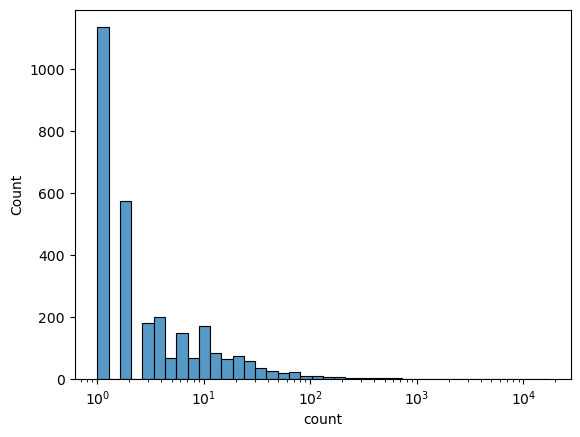

In [67]:
sns.histplot(df, x=df["scaffold"].value_counts(), log_scale=True)

We see that most scaffolds appear less then 100 times. The most common scaffold appears ~17k times

In [68]:
sorted_df = df.sort_values(by="docking_score")
sample = sample_dataset(df.index.to_list(), 1000, df["scaffold"])
dataset = sample.join(df).drop(columns=["molecules", "scaffolds"])

<Axes: xlabel='count', ylabel='Count'>

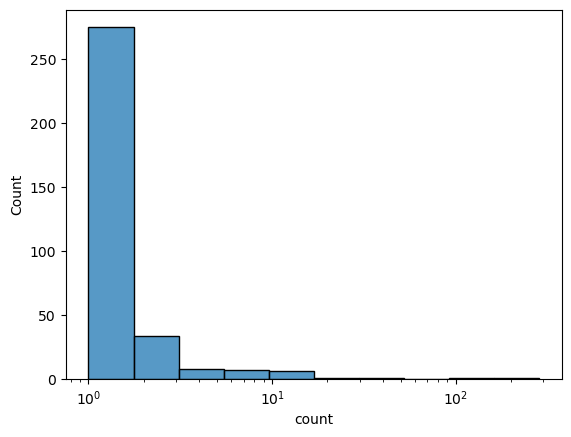

In [69]:
sns.histplot(sample, x=dataset["scaffold"].value_counts(), log_scale=True)

In [70]:
dataset.groupby("scaffold").describe()

target             ... docking_score       
                                               count       mean  ...           75%    max
scaffold                                                         ...                     
C1CCC2NCCC2C1                                    2.0 -14.747166  ...       -6.4955 -6.424
C=C1C2CC(C2)CC1OC(=O)CCc1c[nH]c2ccccc12          1.0 -30.992816  ...       -9.4810 -9.481
C=C1CCCC1OC(=O)CCc1c[nH]c2ccccc12                1.0 -36.870311  ...       -9.3490 -9.349
C=C1CCCCC1OC(=O)CCc1c(-c2ccccc2)[nH]c2ccccc12    1.0 -27.938876  ...       -9.7300 -9.730
C=C1CCCCC1OC(=O)CCc1c[nH]c2ccccc12               1.0 -30.146122  ...       -9.5590 -9.559
...                                              ...        ...  ...           ...    ...
c1ccc2c(CCNC3CCC3)c[nH]c2c1                      1.0 -23.668649  ...       -8.0400 -8.040
c1ccc2c(CCNCC3CC3)c[nH]c2c1                      1.0 -27.060068  ...       -7.5650 -7.565
c1ccc2c(c1)CCN2                                 10.0 -18.465111  ...       -6.6660 -6.575
c1ccccc1                                         6.0 -23.830198  ...       -6.5205 -6.328
c1cncc(-c2cccc3cc[nH]c23)c1                      1.0 -38.379506  ...       -7.7440 -7.744

[334 rows x 16 columns]

<Axes: xlabel='docking_score', ylabel='Count'>

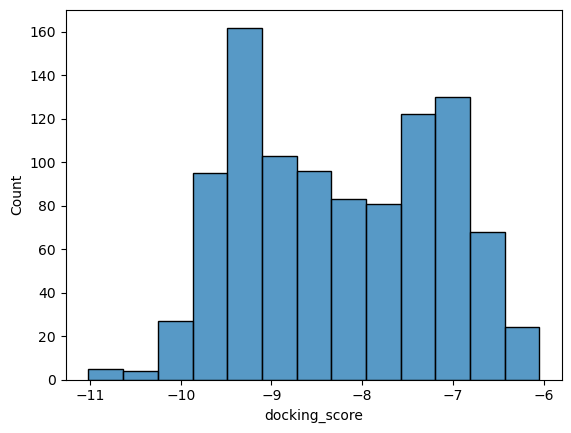

In [71]:
sns.histplot(dataset, x="docking_score")

<Axes: xlabel='target', ylabel='Count'>

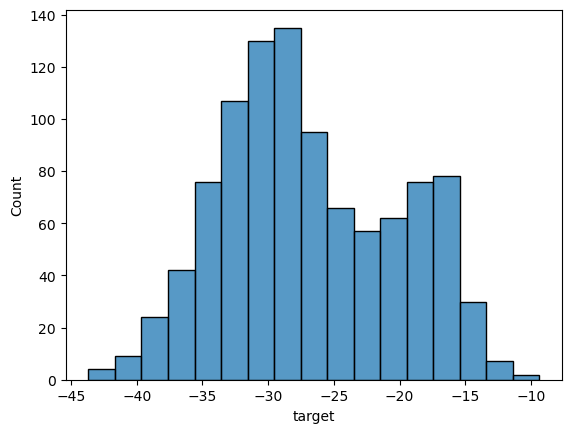

In [72]:
sns.histplot(dataset, x="target")

In [74]:
dataset

,target,smiles,docking_score,scaffold
ZINCc900000021Aj,-13.820722,NC(=O)[C@@H]1C[C@@H]2CCCC[C@@H]2N1,-6.424,C1CCC2NCCC2C1
ZINCc90000002FtJ,-15.673610,NC(=O)[C@@H]1C[C@H]2CCCC[C@@H]2N1,-6.710,C1CCC2NCCC2C1
ZINCoQ0000061U6H,-30.992816,C=C1[C@@H](OC(=O)CCc2c[nH]c3ccccc23)C[C@@H]2C[...,-9.481,C=C1C2CC(C2)CC1OC(=O)CCc1c[nH]c2ccccc12
ZINClH000003vquS,-36.870311,C=C1CCC[C@@H]1OC(=O)CCc1cn(C)c2ccccc12,-9.349,C=C1CCCC1OC(=O)CCc1c[nH]c2ccccc12
ZINCrU000002yIWQ,-27.938876,C=C1CCCC[C@@H]1OC(=O)CCc1c(-c2ccccc2)[nH]c2ccc...,-9.730,C=C1CCCCC1OC(=O)CCc1c(-c2ccccc2)[nH]c2ccccc12
...,...,...,...,...
ZINCdA0000002lJq,-29.630856,C#CCCOc1ccc(Cl)c(C)c1,-6.722,c1ccccc1
ZINCdA0000002n4O,-23.838383,CCCOc1ccc(Cl)c(C#N)c1,-6.328,c1ccccc1
ZINCdA0000002o4F,-21.613146,Cc1cc(C)cc(OCCCF)c1,-6.522,c1ccccc1
ZINCdA0000002o4G,-22.305049,Cc1cc(C)cc(OC[C@@H](C)F)c1,-6.918,c1ccccc1


In [75]:
from rdkit.Chem import rdFingerprintGenerator

mpfgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
molecules = dataset["smiles"].map(Chem.MolFromSmiles).to_list()
X = np.vstack(list(map(mpfgen.GetFingerprintAsNumPy, molecules)))

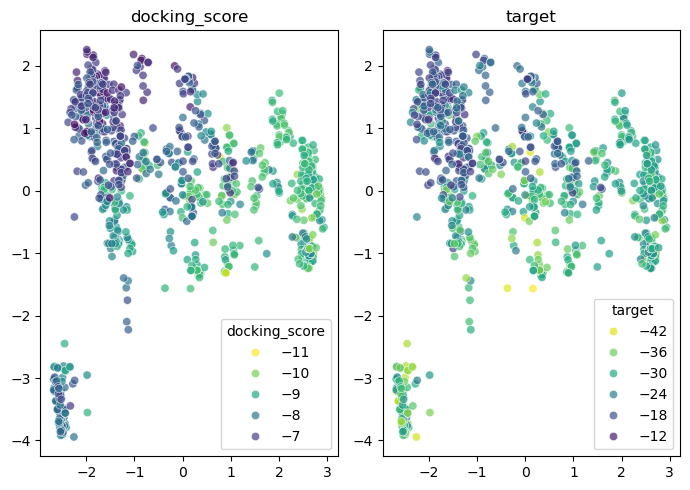

In [79]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings = pca.fit_transform(X)


fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(7, 5))

sns.scatterplot(dataset, x=embeddings[:, 0], y=embeddings[:, 1], hue="docking_score", palette="viridis_r", ax=ax1, alpha=0.7)
sns.scatterplot(dataset, x=embeddings[:, 0], y=embeddings[:, 1], hue="target", palette="viridis_r", ax=ax2, alpha=0.7)

ax1.set_title("docking_score")
ax2.set_title("target")

fig.tight_layout()

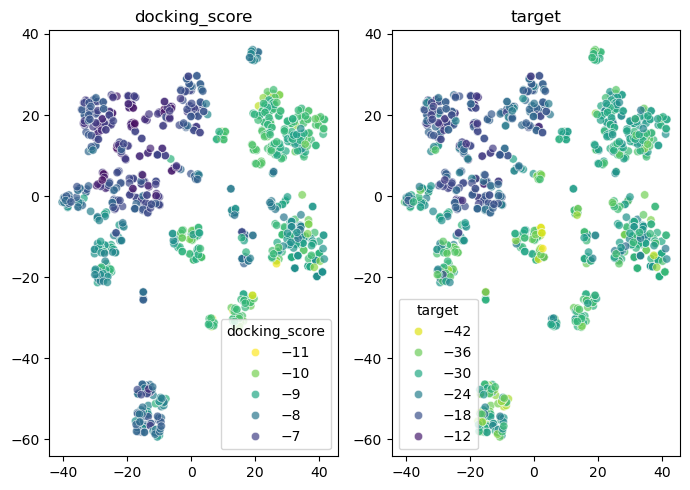

In [80]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
embeddings = tsne.fit_transform(X)


fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(7, 5))

sns.scatterplot(dataset, x=embeddings[:, 0], y=embeddings[:, 1], hue="docking_score", palette="viridis_r", ax=ax1, alpha=0.7)
sns.scatterplot(dataset, x=embeddings[:, 0], y=embeddings[:, 1], hue="target", palette="viridis_r", ax=ax2, alpha=0.7)

ax1.set_title("docking_score")
ax2.set_title("target")

fig.tight_layout()

/home/uds_mara00002/miniforge3/envs/zinc_project/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


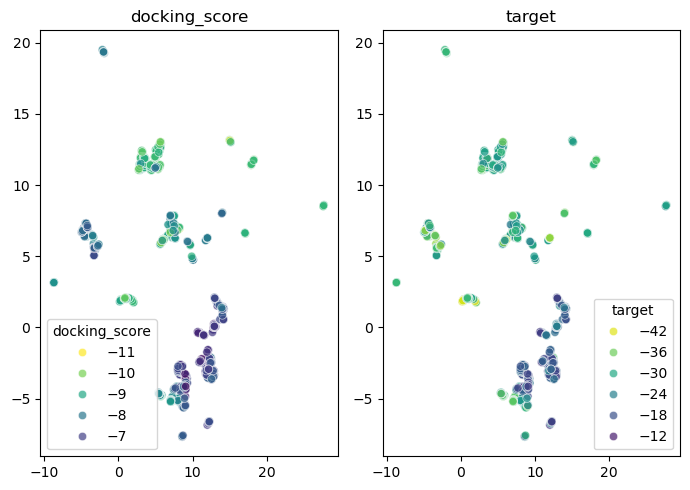

In [81]:
from umap import UMAP

umap_ = UMAP(n_components=2)
embeddings = umap_.fit_transform(X)


fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(7, 5))

sns.scatterplot(dataset, x=embeddings[:, 0], y=embeddings[:, 1], hue="docking_score", palette="viridis_r", ax=ax1, alpha=0.7)
sns.scatterplot(dataset, x=embeddings[:, 0], y=embeddings[:, 1], hue="target", palette="viridis_r", ax=ax2, alpha=0.7)

ax1.set_title("docking_score")
ax2.set_title("target")

fig.tight_layout()